In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

Matplotlib is building the font cache; this may take a moment.


In [3]:
data = pd.read_csv("data/jobs.csv")
data.head()

,job_title,seniority_level,status,company,location,post_date,headquarter,industry,ownership,company_size,revenue,salary,skills
0,data scientist,senior,hybrid,company_003,"Grapevine, TX . Hybrid",17 days ago,"Bentonville, AR, US",Retail,Public,€352.44B,Public,"€100,472 - €200,938","['spark', 'r', 'python', 'scala', 'machine lea..."
1,data scientist,lead,hybrid,company_005,"Fort Worth, TX . Hybrid",15 days ago,"Detroit, MI, US",Manufacturing,Public,"155,030",€51.10B,"€118,733","['spark', 'r', 'python', 'sql', 'machine learn..."
2,data scientist,senior,on-site,company_007,"Austin, TX . Toronto, Ontario, Canada . Kirkla...",a month ago,"Redwood City, CA, US",Technology,Public,"25,930",€33.80B,"€94,987 - €159,559","['aws', 'git', 'python', 'docker', 'sql', 'mac..."
3,data scientist,senior,hybrid,company_008,"Chicago, IL . Scottsdale, AZ . Austin, TX . Hy...",8 days ago,"San Jose, CA, US",Technology,Public,"34,690",€81.71B,"€112,797 - €194,402","['sql', 'r', 'python']"
4,data scientist,NaN,on-site,company_009,On-site,3 days ago,"Stamford, CT, US",Finance,Private,"1,800",Private,"€114,172 - €228,337",[]


In [4]:
import os
os.getcwd()

'c:\\Users\\Administrator\\OneDrive\\Documents\\AI-Job-Market-Intelligence'

In [5]:
os.listdir()

['.venv',
 'app.py',
 'dashboard',
 'data',
 'job_market_analysis.ipynb',
 'models',
 'notebooks',
 'src',
 'venv',
 'webapp']

In [6]:
os.listdir("data")

['jobs.csv']

In [7]:
import pandas as pd

data = pd.read_csv("data/jobs.csv")
data.head()

,job_title,seniority_level,status,company,location,post_date,headquarter,industry,ownership,company_size,revenue,salary,skills
0,data scientist,senior,hybrid,company_003,"Grapevine, TX . Hybrid",17 days ago,"Bentonville, AR, US",Retail,Public,€352.44B,Public,"€100,472 - €200,938","['spark', 'r', 'python', 'scala', 'machine lea..."
1,data scientist,lead,hybrid,company_005,"Fort Worth, TX . Hybrid",15 days ago,"Detroit, MI, US",Manufacturing,Public,"155,030",€51.10B,"€118,733","['spark', 'r', 'python', 'sql', 'machine learn..."
2,data scientist,senior,on-site,company_007,"Austin, TX . Toronto, Ontario, Canada . Kirkla...",a month ago,"Redwood City, CA, US",Technology,Public,"25,930",€33.80B,"€94,987 - €159,559","['aws', 'git', 'python', 'docker', 'sql', 'mac..."
3,data scientist,senior,hybrid,company_008,"Chicago, IL . Scottsdale, AZ . Austin, TX . Hy...",8 days ago,"San Jose, CA, US",Technology,Public,"34,690",€81.71B,"€112,797 - €194,402","['sql', 'r', 'python']"
4,data scientist,NaN,on-site,company_009,On-site,3 days ago,"Stamford, CT, US",Finance,Private,"1,800",Private,"€114,172 - €228,337",[]


In [8]:
data.columns

Index(['job_title', 'seniority_level', 'status', 'company', 'location',
       'post_date', 'headquarter', 'industry', 'ownership', 'company_size',
       'revenue', 'salary', 'skills'],
      dtype='object')

In [9]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 944 entries, 0 to 943
Data columns (total 13 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   job_title        941 non-null    object
 1   seniority_level  884 non-null    object
 2   status           688 non-null    object
 3   company          944 non-null    object
 4   location         942 non-null    object
 5   post_date        944 non-null    object
 6   headquarter      944 non-null    object
 7   industry         944 non-null    object
 8   ownership        897 non-null    object
 9   company_size     944 non-null    object
 10  revenue          929 non-null    object
 11  salary           944 non-null    object
 12  skills           944 non-null    object
dtypes: object(13)
memory usage: 96.0+ KB


In [10]:
data.isnull().sum()

job_title            3
seniority_level     60
status             256
company              0
location             2
post_date            0
headquarter          0
industry             0
ownership           47
company_size         0
revenue             15
salary               0
skills               0
dtype: int64

In [11]:
data = data.fillna("Unknown")

In [12]:
data.isnull().sum()

job_title          0
seniority_level    0
status             0
company            0
location           0
post_date          0
headquarter        0
industry           0
ownership          0
company_size       0
revenue            0
salary             0
skills             0
dtype: int64

In [13]:
data["post_date"] = pd.to_datetime(data["post_date"], errors="coerce")

C:\Users\Administrator\AppData\Local\Temp\ipykernel_20868\3997208657.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  data["post_date"] = pd.to_datetime(data["post_date"], errors="coerce")


In [14]:
data.dtypes

job_title                  object
seniority_level            object
status                     object
company                    object
location                   object
post_date          datetime64[ns]
headquarter                object
industry                   object
ownership                  object
company_size               object
revenue                    object
salary                     object
skills                     object
dtype: object

In [15]:
data["job_title"].value_counts().head(10)

job_title
data scientist               856
machine learning engineer     80
data engineer                  4
Unknown                        3
data analyst                   1
Name: count, dtype: int64

In [16]:
skills_series = data["skills"].str.split(",").explode()
skills_series.value_counts().head(20)

skills
 'machine learning'     428
 'python'               399
 'sql'                  307
 'r'                    304
 'python']              223
[]                      201
 'aws'                  151
 'tensorflow']          145
['sql'                  133
 'deep learning'        110
['pytorch'              106
 'gcp'                  103
['spark'                 96
 'azure'                 93
 'machine learning']     90
 'tableau']              86
 'scikit-learn'          84
 'scala'                 83
['pandas'                76
 'database'              68
Name: count, dtype: int64

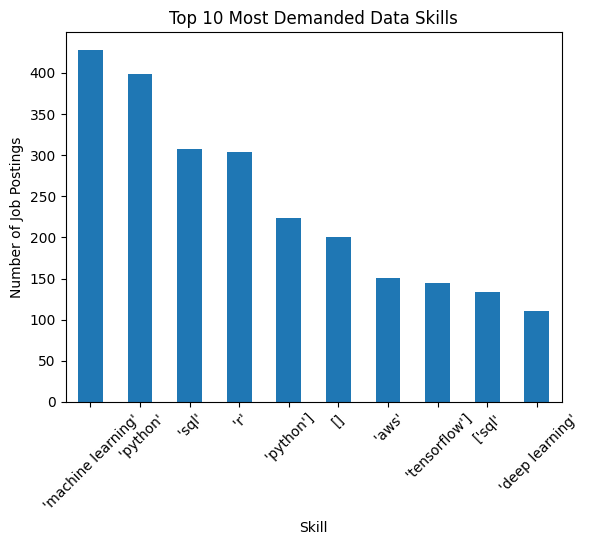

In [17]:
import matplotlib.pyplot as plt

skills_series.value_counts().head(10).plot(kind="bar")
plt.title("Top 10 Most Demanded Data Skills")
plt.xlabel("Skill")
plt.ylabel("Number of Job Postings")
plt.xticks(rotation=45)
plt.show()

In [18]:
data["job_title"].value_counts().head(10)

job_title
data scientist               856
machine learning engineer     80
data engineer                  4
Unknown                        3
data analyst                   1
Name: count, dtype: int64

In [19]:
data["job_title"].value_counts().head(10)

job_title
data scientist               856
machine learning engineer     80
data engineer                  4
Unknown                        3
data analyst                   1
Name: count, dtype: int64

In [20]:
data = data[data["job_title"] != "Unknown"]

In [21]:
data["job_title"].value_counts()

job_title
data scientist               856
machine learning engineer     80
data engineer                  4
data analyst                   1
Name: count, dtype: int64

In [22]:
data["job_title"] = data["job_title"].str.lower()

In [23]:
data["job_title"].value_counts()

job_title
data scientist               856
machine learning engineer     80
data engineer                  4
data analyst                   1
Name: count, dtype: int64

In [24]:
skills_series = data["skills"].str.lower().str.split(",").explode()
skills_series = skills_series.str.strip()

skills_series.value_counts().head(20)

skills
'machine learning'     428
'python'               398
'sql'                  307
'r'                    303
'python']              222
[]                     201
'aws'                  151
'tensorflow']          145
['sql'                 133
'deep learning'        110
['pytorch'             106
'gcp'                  102
['spark'                96
'azure'                 93
'machine learning']     90
'tableau']              86
'scikit-learn'          84
'scala'                 83
['pandas'               76
'database'              68
Name: count, dtype: int64

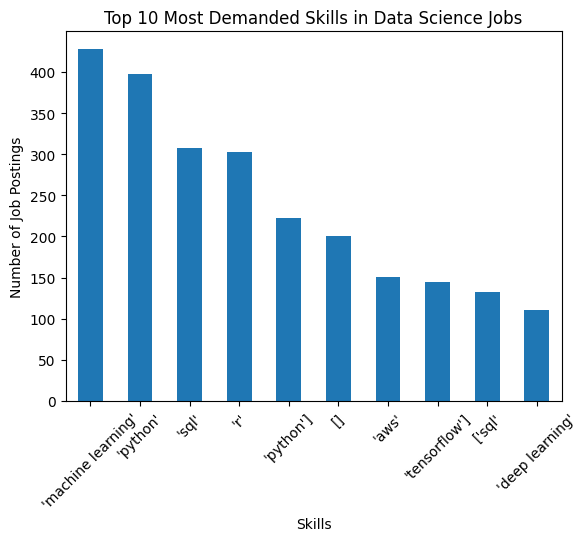

In [25]:
import matplotlib.pyplot as plt

top_skills = skills_series.value_counts().head(10)

top_skills.plot(kind="bar")

plt.title("Top 10 Most Demanded Skills in Data Science Jobs")
plt.xlabel("Skills")
plt.ylabel("Number of Job Postings")

plt.xticks(rotation=45)

plt.show()

In [26]:
skills_series.value_counts().head(20)

skills
'machine learning'     428
'python'               398
'sql'                  307
'r'                    303
'python']              222
[]                     201
'aws'                  151
'tensorflow']          145
['sql'                 133
'deep learning'        110
['pytorch'             106
'gcp'                  102
['spark'                96
'azure'                 93
'machine learning']     90
'tableau']              86
'scikit-learn'          84
'scala'                 83
['pandas'               76
'database'              68
Name: count, dtype: int64

In [27]:
data["skills"] = data["skills"].str.replace("[", "", regex=False)
data["skills"] = data["skills"].str.replace("]", "", regex=False)
data["skills"] = data["skills"].str.replace("'", "", regex=False)

In [28]:
skills_series = data["skills"].str.lower().str.split(",").explode()
skills_series = skills_series.str.strip()

In [29]:
skills_series = skills_series[skills_series != ""]

In [30]:
skills_series.value_counts().head(20)

skills
python              638
machine learning    580
sql                 442
r                   342
aws                 217
deep learning       178
tensorflow          165
spark               161
azure               154
pytorch             148
tableau             116
gcp                 105
scikit-learn         91
scala                85
database             83
pandas               76
java                 73
hadoop               67
git                  64
numpy                60
Name: count, dtype: int64

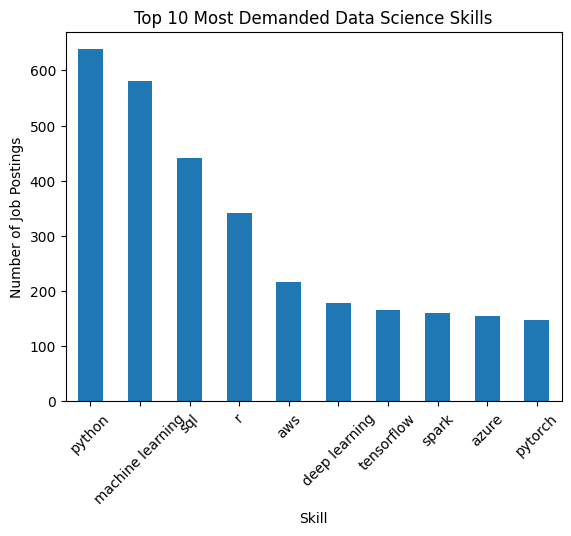

In [31]:
import matplotlib.pyplot as plt

top_skills = skills_series.value_counts().head(10)

top_skills.plot(kind="bar")

plt.title("Top 10 Most Demanded Data Science Skills")
plt.xlabel("Skill")
plt.ylabel("Number of Job Postings")

plt.xticks(rotation=45)

plt.show()

In [32]:
skills_series.value_counts().head(15)


skills
python              638
machine learning    580
sql                 442
r                   342
aws                 217
deep learning       178
tensorflow          165
spark               161
azure               154
pytorch             148
tableau             116
gcp                 105
scikit-learn         91
scala                85
database             83
Name: count, dtype: int64

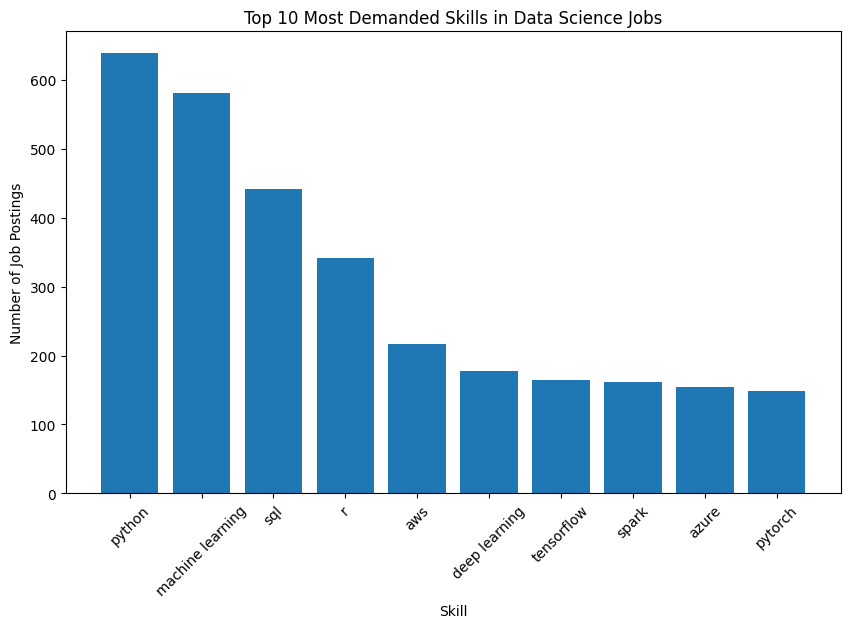

In [33]:
import matplotlib.pyplot as plt

top_skills = skills_series.value_counts().head(10)

plt.figure(figsize=(10,6))
plt.bar(top_skills.index, top_skills.values)

plt.title("Top 10 Most Demanded Skills in Data Science Jobs")
plt.xlabel("Skill")
plt.ylabel("Number of Job Postings")

plt.xticks(rotation=45)

plt.show()

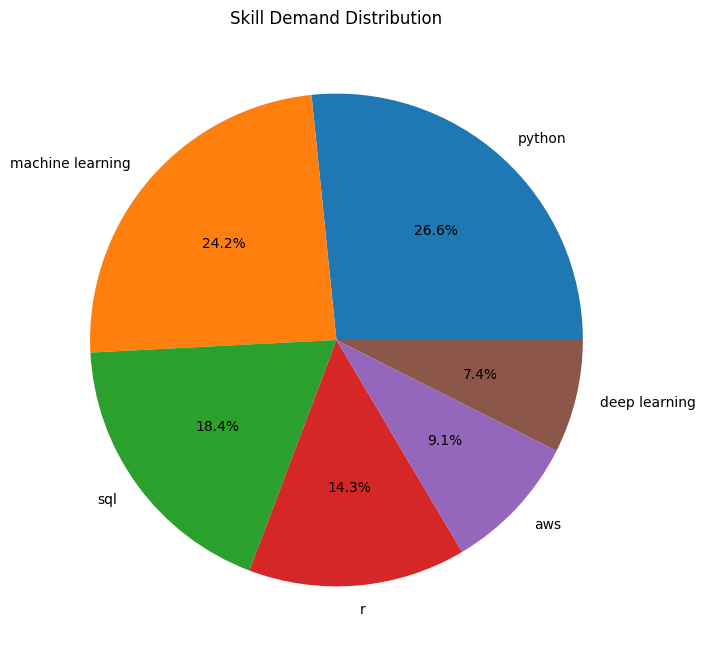

In [34]:
top_skills = skills_series.value_counts().head(6)

plt.figure(figsize=(8,8))
plt.pie(top_skills.values, labels=top_skills.index, autopct="%1.1f%%")

plt.title("Skill Demand Distribution")

plt.show()

In [35]:
job_skills = data["skills"].str.lower().str.split(",")

job_skills.head()


0    [spark,  r,  python,  scala,  machine learning...
1        [spark,  r,  python,  sql,  machine learning]
2    [aws,  git,  python,  docker,  sql,  machine l...
3                                   [sql,  r,  python]
4                                                   []
Name: skills, dtype: object

In [36]:
def recommend_skills(user_skills):

    user_skills = [s.lower() for s in user_skills]

    recommendations = {}

    for skills in job_skills:
        for skill in skills:
            skill = skill.strip()
            if skill not in user_skills:
                recommendations[skill] = recommendations.get(skill,0) + 1

    sorted_skills = sorted(recommendations.items(), key=lambda x: x[1], reverse=True)

    return sorted_skills[:10]

In [37]:
recommend_skills(["python","sql"])

[('machine learning', 580),
 ('r', 342),
 ('aws', 217),
 ('', 201),
 ('deep learning', 178),
 ('tensorflow', 165),
 ('spark', 161),
 ('azure', 154),
 ('pytorch', 148),
 ('tableau', 116)]

In [38]:
recommend_skills(["python","sql"])

[('machine learning', 580),
 ('r', 342),
 ('aws', 217),
 ('', 201),
 ('deep learning', 178),
 ('tensorflow', 165),
 ('spark', 161),
 ('azure', 154),
 ('pytorch', 148),
 ('tableau', 116)]

In [39]:
job_skills = data["skills"].str.lower().str.split(",")

job_skills = job_skills.apply(lambda skills: [s.strip() for s in skills if s.strip() != ""])

In [40]:
def recommend_skills(user_skills):

    user_skills = [s.lower() for s in user_skills]

    recommendations = {}

    for skills in job_skills:
        for skill in skills:

            if skill not in user_skills:
                recommendations[skill] = recommendations.get(skill, 0) + 1

    sorted_skills = sorted(recommendations.items(), key=lambda x: x[1], reverse=True)

    return sorted_skills[:10]

In [41]:
recommend_skills(["python","sql"])

[('machine learning', 580),
 ('r', 342),
 ('aws', 217),
 ('deep learning', 178),
 ('tensorflow', 165),
 ('spark', 161),
 ('azure', 154),
 ('pytorch', 148),
 ('tableau', 116),
 ('gcp', 105)]

In [42]:
data["salary"].head(10)

0    €100,472 - €200,938
1               €118,733
2     €94,987 - €159,559
3    €112,797 - €194,402
4    €114,172 - €228,337
5    €196,371 - €251,170
6      €51,330 - €70,144
7    €121,480 - €132,440
8               €207,331
9               €219,201
Name: salary, dtype: object

In [43]:
data["salary"].unique()[:10]

array(['€100,472 - €200,938', '€118,733', '€94,987 - €159,559',
       '€112,797 - €194,402', '€114,172 - €228,337',
       '€196,371 - €251,170', '€51,330 - €70,144', '€121,480 - €132,440',
       '€207,331', '€219,201'], dtype=object)

In [44]:
data["salary"] = data["salary"].str.replace("€", "", regex=False)
data["salary"] = data["salary"].str.replace(",", "", regex=False)

In [45]:
def convert_salary(salary):

    if "-" in salary:
        low, high = salary.split("-")
        return (float(low) + float(high)) / 2
    else:
        return float(salary)

In [46]:
data["salary_numeric"] = data["salary"].apply(convert_salary)

In [47]:
data[["salary", "salary_numeric"]].head(10)

,salary,salary_numeric
0,100472 - 200938,150705.0
1,118733,118733.0
2,94987 - 159559,127273.0
3,112797 - 194402,153599.5
4,114172 - 228337,171254.5
5,196371 - 251170,223770.5
6,51330 - 70144,60737.0
7,121480 - 132440,126960.0
8,207331,207331.0
9,219201,219201.0


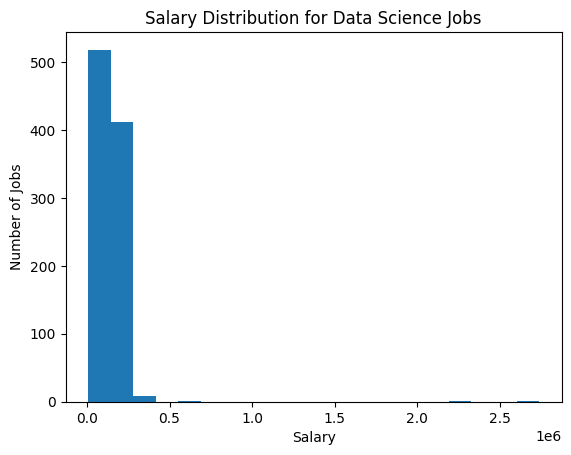

In [48]:
import matplotlib.pyplot as plt

plt.hist(data["salary_numeric"], bins=20)

plt.title("Salary Distribution for Data Science Jobs")
plt.xlabel("Salary")
plt.ylabel("Number of Jobs")

plt.show()

In [49]:
data["salary_numeric"].head()

0    150705.0
1    118733.0
2    127273.0
3    153599.5
4    171254.5
Name: salary_numeric, dtype: float64

In [50]:
data["salary_numeric"].describe()

count    9.410000e+02
mean     1.318325e+05
std      1.289024e+05
min      7.055000e+03
25%      7.672400e+04
50%      1.347245e+05
75%      1.697330e+05
max      2.739979e+06
Name: salary_numeric, dtype: float64

In [51]:
data = data[data["salary_numeric"] < 500000]

In [52]:
data["salary_numeric"].describe()

count       938.000000
mean     126217.208955
std       64518.495661
min        7055.000000
25%       76460.000000
50%      134722.500000
75%      169155.000000
max      306626.000000
Name: salary_numeric, dtype: float64

In [53]:
features = data[["job_title", "company_size", "industry"]]
target = data["salary_numeric"]

In [54]:
features_encoded = pd.get_dummies(features)

In [55]:
features_encoded.head()

,job_title_data analyst,job_title_data engineer,job_title_data scientist,job_title_machine learning engineer,"company_size_1,020","company_size_1,040","company_size_1,050","company_size_1,060","company_size_1,230","company_size_1,260",...,company_size_€352.44B,company_size_€354.99B,industry_Education,industry_Energy,industry_Finance,industry_Healthcare,industry_Logistics,industry_Manufacturing,industry_Retail,industry_Technology
0,False,False,True,False,False,False,False,False,False,False,...,True,False,False,False,False,False,False,False,True,False
1,False,False,True,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,True,False,False
2,False,False,True,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,True
3,False,False,True,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,True
4,False,False,True,False,False,False,False,False,False,False,...,False,False,False,False,True,False,False,False,False,False


In [56]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    features_encoded,
    target,
    test_size=0.2,
    random_state=42
)

In [57]:
from sklearn.ensemble import RandomForestRegressor

model = RandomForestRegressor()

model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsample

In [58]:
from sklearn.metrics import mean_absolute_error

predictions = model.predict(X_test)

mae = mean_absolute_error(y_test, predictions)

print("Mean Absolute Error:", mae)

Mean Absolute Error: 48086.69879887514


In [59]:
features_encoded.shape

(938, 519)

In [60]:
print("Mean Absolute Error:", mae)

Mean Absolute Error: 48086.69879887514


In [61]:
code app.py

SyntaxError: invalid syntax (491572999.py, line 1)